<a href="https://colab.research.google.com/github/gautamkr1876/AIML_ClassNotes/blob/main/7.%20Advanced%20AI%20Agents/12.%20Dataset%20Engineering%20%26%26%20Inference%20Optimization%20/LLM_Inference_Optimization.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# LLM Inference Optimization: KV Caching & Speculative Decoding

This notebook walks through two of the most important techniques that make modern LLM serving fast:

- **KV Caching** — the workhorse that turns autoregressive decoding from O(n²) into something tractable, and the reason your GPU memory balloons as sequences get longer.
- **Speculative Decoding** — a trick to break the "one forward pass = one token" bottleneck by letting a small draft model propose, and a large target model verify.

Theory and visuals throughout are drawn from Aleksa Gordić's excellent deep dive *Inside vLLM: Anatomy of a High-Throughput LLM Inference System* (https://www.aleksagordic.com/blog/vllm). The hands-on code uses small open models (`gpt2`, `gpt2-medium`) so everything runs on a free Colab T4.

## Setup

Install dependencies and import the libraries we'll use throughout. On Colab the first cell will take ~30 seconds.

In [ ]:
!pip install -q transformers torch accelerate matplotlib

In [ ]:
import os
import gc
import time
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.bfloat16 if device == "cuda" and torch.cuda.is_bf16_supported() else torch.float32

print(f"device: {device}")
print(f"dtype:  {dtype}")
if device != "cuda":
    print("⚠️  Running on CPU. Memory measurements in the KV cache section won't work; "
          "consider switching to a GPU runtime (Runtime → Change runtime type → T4).")

device: cuda
dtype:  torch.bfloat16


---

# Part 1 — KV Caching

## Why we need it

Transformers are autoregressive at inference time: to generate token *t+1* the model attends over tokens *1…t*. The naive thing to do is, at every step, re-run the full forward pass over the entire sequence so far. That is wasteful — for every token in the prompt, the Key and Value projections were already computed at the previous step. Recomputing them is a pure tax on latency.

KV caching is the obvious fix: after each forward pass, **store** the K and V tensors for every token at every layer in a per-request buffer (the "KV cache"). On the next step, only the newest token needs its K, V, and Q computed; it queries against the cached K/V of all earlier tokens. The cost per generated token drops from O(seq_len) attention work to O(1) — at the price of memory that grows linearly with sequence length.

In production engines like vLLM, the cache isn't one big contiguous tensor per request — it's chopped into fixed-size blocks (typically 16 tokens each) and managed by a pool. This is **paged attention**: each request holds a list of block IDs pointing into a shared KV memory pool, the same way an OS pages virtual memory.

![KV cache blocks](https://www.aleksagordic.com/blog/vllm/kv_cache_blocks.png)

*KV cache blocks — each request maintains a list of block handles into a shared pool. Image: Aleksa Gordić, "Inside vLLM".*

The forward pass then flattens many requests into one long "super sequence" and uses the block tables plus a `slot_mapping` so each token writes its K/V into the right block slot. This is what enables continuous batching: requests with different lengths sit side by side without padding.

![Forward pass with continuous batching and paged attention](https://www.aleksagordic.com/blog/vllm/fwd_pass.png)

*Forward pass: continuous batching and paged attention. Image: Aleksa Gordić, "Inside vLLM".*

We won't reimplement paged attention here — that's a serious engineering project. Instead we'll use Hugging Face `transformers`, where `model.generate()` already manages a (non-paged) KV cache under the hood via the `use_cache=True` flag, and we'll observe its effects directly.

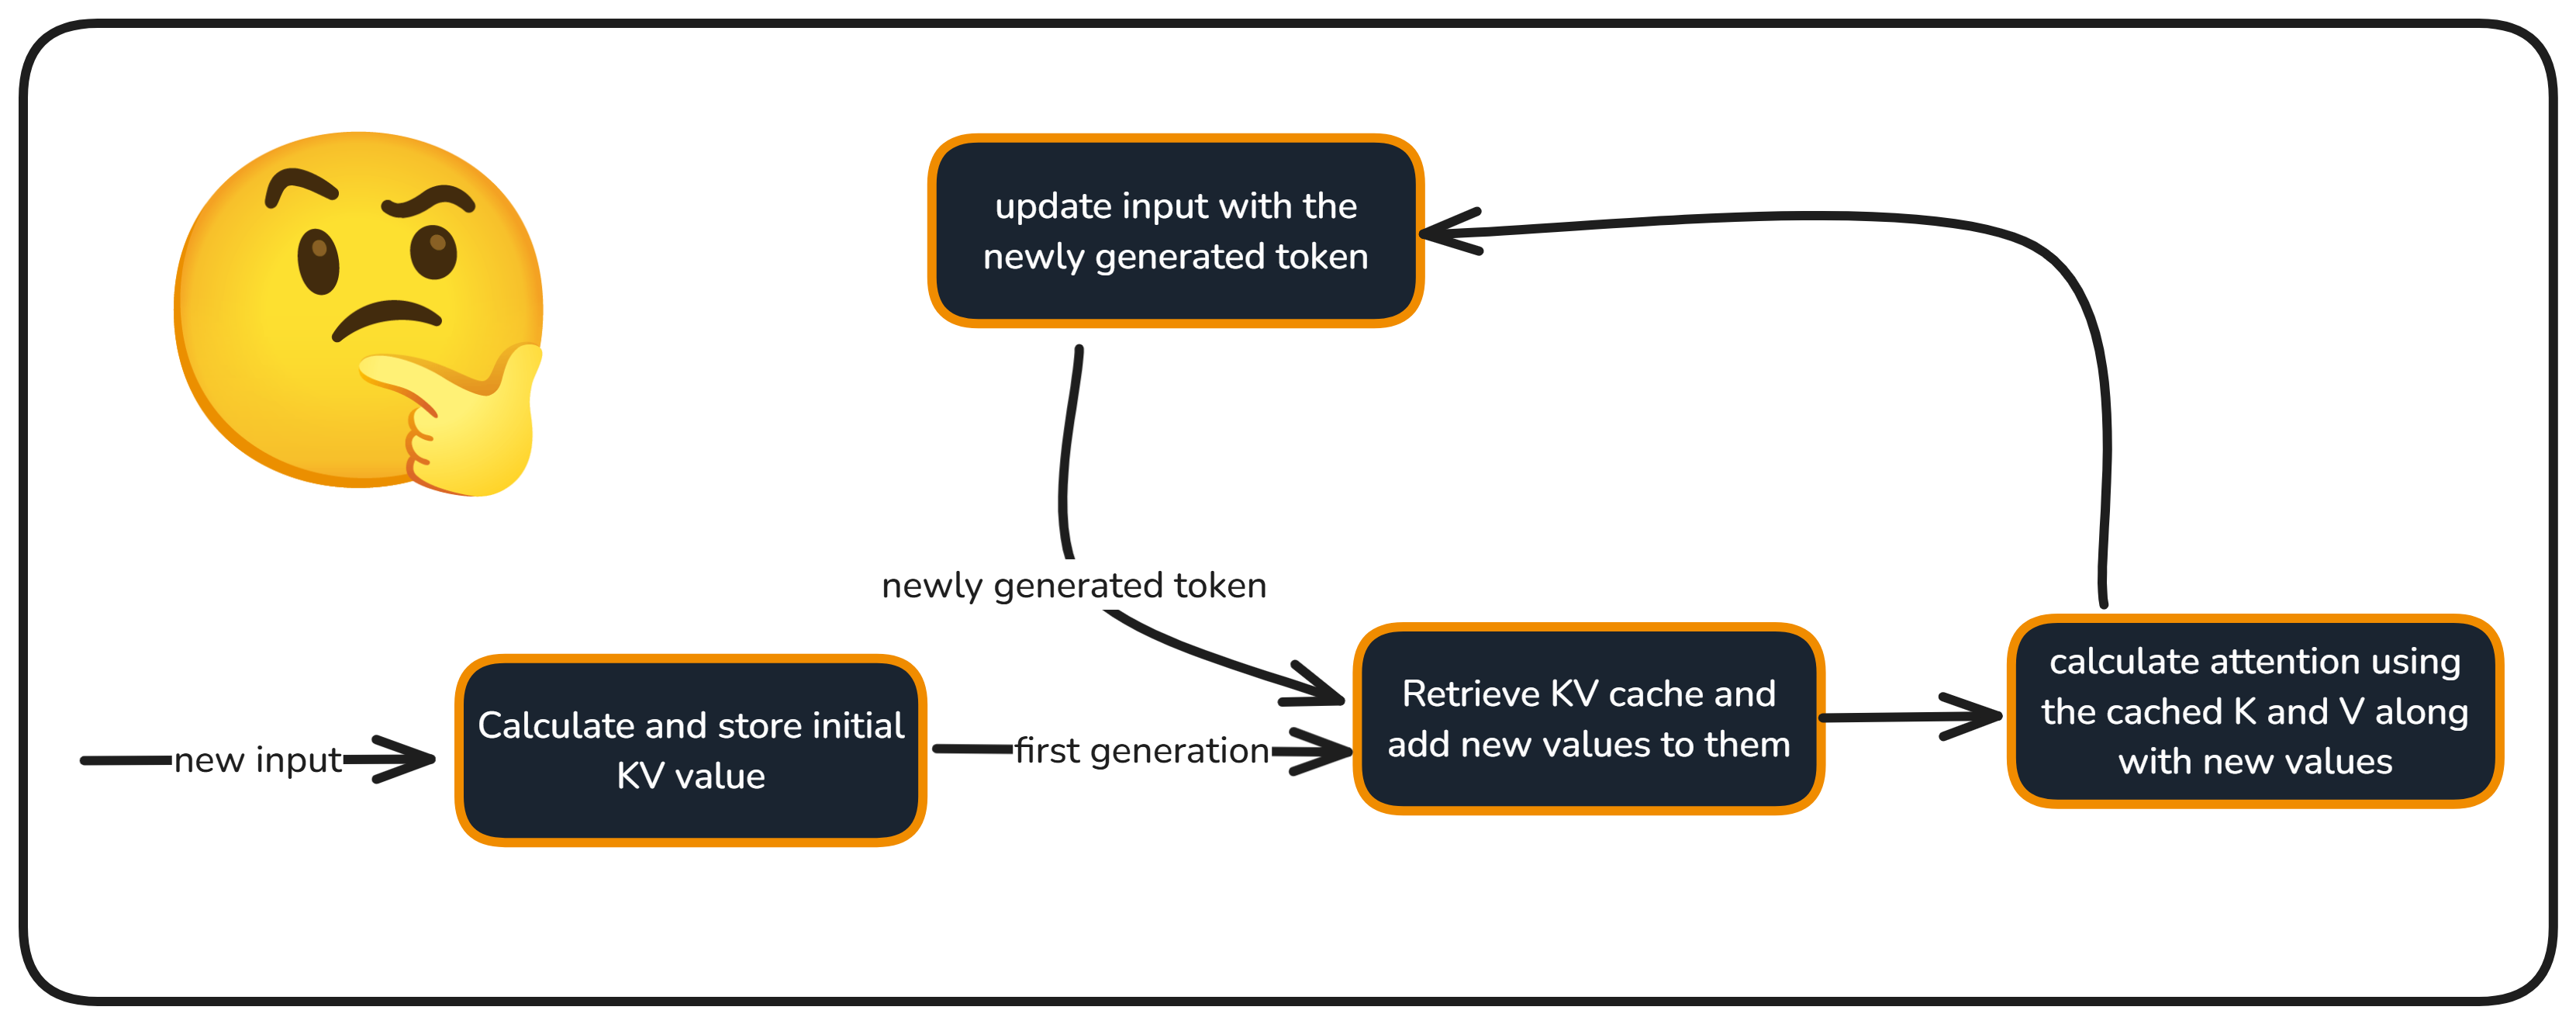

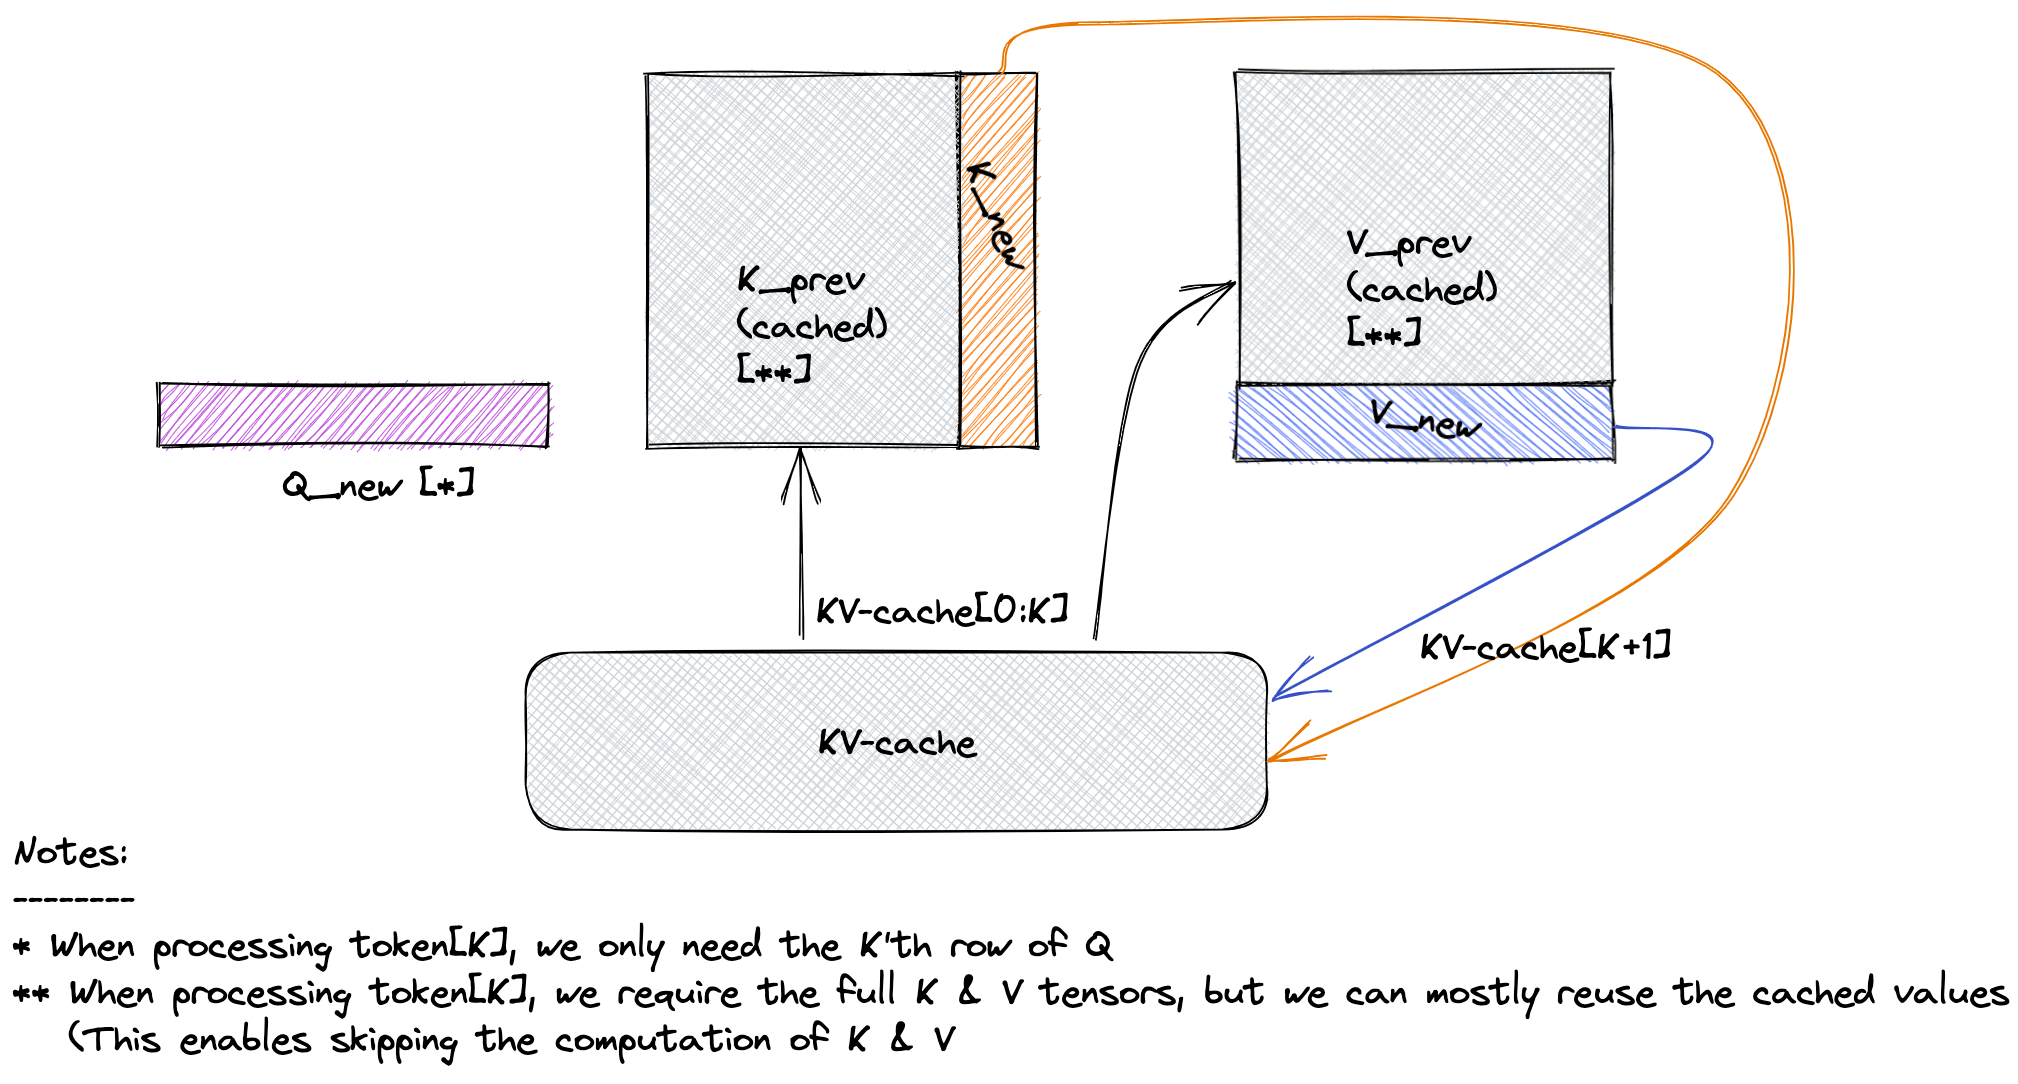

## Demo 1 — KV caching in action

Let's load a small model and call `generate()`. The `use_cache=True` argument is on by default for autoregressive models; we set it explicitly to make the intent clear.

In [ ]:
MODEL_NAME = "gpt2"  # 124M params — fits anywhere

print(f"Loading {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=dtype).to(device)
model.config.pad_token_id = model.config.eos_token_id
model.eval()
print("Loaded.")

Loading gpt2...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded.


In [ ]:
prompt = "The best way to optimize LLM inference is"
inputs = tokenizer(prompt, return_tensors="pt").to(device)
print(f'Prompt: "{prompt}"')

Prompt: "The best way to optimize LLM inference is"


In [ ]:
print("Running model.generate() with use_cache=True ...")

start = time.perf_counter()
with torch.no_grad():
    outputs = model.generate(
        inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=50,
        use_cache=True,
        pad_token_id=tokenizer.pad_token_id,
        do_sample=False,
    )
elapsed = time.perf_counter() - start

generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
print("--- Generated ---")
print(generated_text)
print(f"\n({elapsed:.3f}s for 50 tokens)")

Running model.generate() with use_cache=True ...
--- Generated ---
The best way to optimize LLM inference is to use the LLVM's built-in type inference.

The LLVM's built-in type inference is a way to infer the type of a type.

The LLVM's built-in type inference is a way to infer

(1.562s for 50 tokens)


### What just happened, step by step

**Stage 1 — Prefill (the first pass).** The model processes the entire prompt in a single forward pass. For every token it computes the per-layer K and V projections and writes them into the cache (`past_key_values`). This step is **compute-bound** — lots of tokens, lots of FLOPs — but it only happens once per request.

**Stage 2 — Decode (the token-by-token loop).** To produce the first new token, the model only runs a forward pass over the *last* token. It computes Q for that single token and attends against everything already in the cache. The new token's K/V is appended to the cache. To produce the second new token, only that token is processed — it attends against (prompt + 1 new token) of cached K/V. And so on.

This is the asymmetry the blog highlights: **prefill is compute-bound, decode is memory-bandwidth-bound.** Decode steps still need to load all the model weights from HBM just to process one token, which is why batching multiple decode requests together is so valuable — the weight I/O gets amortized.

## Demo 2 — Quantifying KV cache memory growth

The cache isn't free. Every generated token adds K and V vectors at every layer for every attention head. For a model with `L` layers, `H` KV heads, head dim `d`, and dtype size `b` bytes, each token costs:

```
2 (K and V) × L × H × d × b   bytes per token
```

Let's measure this empirically. We'll generate runs of increasing length and record peak GPU memory after each.

In [ ]:
if device != "cuda":
    print("Skipping — needs CUDA for torch.cuda.max_memory_allocated().")
else:
    def peak_mb():
        return torch.cuda.max_memory_allocated() / (1024 ** 2)

    generation_lengths = [50, 100, 200, 400, 800]
    peak_memory_mb = []

    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    baseline_mb = peak_mb()
    print(f"Baseline (model only): {baseline_mb:.2f} MB")

    for length in generation_lengths:
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        torch.cuda.reset_peak_memory_stats()
        with torch.no_grad():
            model.generate(
                inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                max_new_tokens=length,
                use_cache=True,
                pad_token_id=tokenizer.pad_token_id,
                do_sample=False,
            )
        torch.cuda.synchronize()
        run_peak = peak_mb()
        peak_memory_mb.append(run_peak)
        print(f"  {length:4d} new tokens → peak {run_peak:.2f} MB")

        del inputs
        torch.cuda.empty_cache()
        gc.collect()

Baseline (model only): 264.61 MB
    50 new tokens → peak 267.13 MB
   100 new tokens → peak 268.89 MB
   200 new tokens → peak 272.43 MB
   400 new tokens → peak 279.76 MB
   800 new tokens → peak 306.45 MB



Generated tokens | Peak memory (MB)
-----------------|------------------
              50 |            267.13
             100 |            268.89
             200 |            272.43
             400 |            279.76
             800 |            306.45


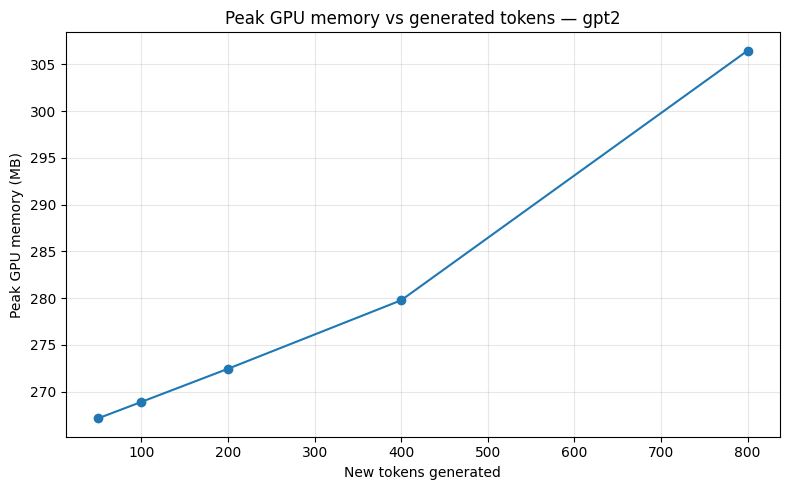


Approx memory growth: 53.7 KB / token


In [ ]:
if device == "cuda":
    print("\nGenerated tokens | Peak memory (MB)")
    print("-----------------|------------------")
    for n, m in zip(generation_lengths, peak_memory_mb):
        print(f"{n:16d} | {m:17.2f}")

    plt.figure(figsize=(8, 5))
    plt.plot(generation_lengths, peak_memory_mb, marker="o")
    plt.title(f"Peak GPU memory vs generated tokens — {MODEL_NAME}")
    plt.xlabel("New tokens generated")
    plt.ylabel("Peak GPU memory (MB)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    if len(peak_memory_mb) > 1:
        slope = (peak_memory_mb[-1] - peak_memory_mb[0]) / (generation_lengths[-1] - generation_lengths[0])
        print(f"\nApprox memory growth: {slope*1024:.1f} KB / token")

### Reading the plot

You should see an almost perfectly linear curve. The **intercept** is roughly the model weights; the **slope** is the per-token KV cost. For `gpt2` (12 layers × 12 heads × 64 dim × 2 bytes for fp16 × 2 for K+V) the theoretical cost is about 36 KB per token — what you measure should be in that ballpark, plus a bit of activation/scratch overhead.

This linear scaling is the entire reason production engines obsess over KV cache memory. It is also why every recent architecture trick — **GQA** (Grouped-Query Attention), **MLA** (Multi-Head Latent Attention from DeepSeek), KV cache quantization, paged attention, prefix caching — is fundamentally aimed at making this slope smaller or this memory more reusable across requests.

---

# Part 2 — Speculative Decoding

## The bottleneck

Even with a perfect KV cache, decode is fundamentally serial: one forward pass through the big model produces exactly one token. At small batch sizes that step is memory-bandwidth-bound — you've paid to stream all of the model's weights through HBM, just to predict a single token. That's a lot of bandwidth for very little arithmetic.

Speculative decoding (Leviathan et al., Chen et al., 2023) breaks this 1:1 ratio by introducing a second, smaller **draft model**:

1. **Draft.** The small model cheaply proposes `k` candidate tokens by running its own short autoregressive loop.
2. **Verify.** The large model runs **one** forward pass over `context + k draft tokens`. Because transformers process all positions in parallel, this single pass produces the large model's predicted distribution at each of the `k` positions, plus one extra distribution for position `k+1`.
3. **Accept / reject.** Walk left-to-right through the drafts. For each position, accept the draft token if the large model's probability for it is at least as high as the draft's; otherwise accept it stochastically with probability `p_large(token) / p_draft(token)`. Stop at the first rejection. If everything was accepted, sample one bonus token from the large model's `k+1`-th distribution for free. If something was rejected, sample a corrected token from the rebalanced distribution `max(0, p_large - p_draft)` (renormalized).

The math (see the original paper) guarantees that the accepted sequence is distributed **exactly** as if you'd sampled token-by-token from the large model. There is no quality loss. The win is that a single expensive large-model pass yields up to `k+1` tokens instead of 1.

![Drafting stage](https://www.aleksagordic.com/blog/vllm/specdec_pt1.png)

*Drafting stage — the small model proposes k tokens. Image: Aleksa Gordić, "Inside vLLM".*

![Verification and rejection sampling stage](https://www.aleksagordic.com/blog/vllm/specdec_pt2.png)

*Verify and rejection-sampling stage. Image: Aleksa Gordić, "Inside vLLM".*

vLLM V1 actually doesn't ship a generic small-LM draft path; it implements faster proposal schemes — **n-gram lookup** (search the existing context for a recurring n-gram and reuse the tokens that followed it), **EAGLE** (replace most of the large model with a lightweight MLP draft head), and **Medusa** (extra linear heads predicting `k` future tokens in parallel). The accept/reject machinery is the same.

Below we build the simpler "two LMs" version so the mechanics are visible. We'll do **greedy** acceptance (accept iff the draft's argmax matches the target's argmax) — this is the deterministic special case and is the easiest way to see the logic.

## Demo 3 — A single speculative decoding step

Two players:
- **Draft (`gpt2`):** small, fast, the scout that runs ahead.
- **Target (`gpt2-medium`):** larger, slower, the general who has the final say.

In [ ]:
TARGET_MODEL_NAME = "gpt2-medium"
DRAFT_MODEL_NAME  = "gpt2"
K_DRAFT_TOKENS = 5

INITIAL_CONTEXT_TEXT = "There are different ways to optimize LLM inference. One"

# Reuse the gpt2 tokenizer — gpt2 and gpt2-medium share it
spec_tokenizer = AutoTokenizer.from_pretrained(DRAFT_MODEL_NAME)
if spec_tokenizer.pad_token is None:
    spec_tokenizer.pad_token = spec_tokenizer.eos_token

print(f"Loading target model: {TARGET_MODEL_NAME} ...")
target_model = AutoModelForCausalLM.from_pretrained(TARGET_MODEL_NAME).to(device)
target_model.eval()

print(f"Loading draft model:  {DRAFT_MODEL_NAME} ...")
draft_model = AutoModelForCausalLM.from_pretrained(DRAFT_MODEL_NAME).to(device)
draft_model.eval()
print("Both loaded.")

Loading target model: gpt2-medium ...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading draft model:  gpt2 ...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Both loaded.


### Step 1 — The scout runs ahead

The small draft model autoregressively generates `K` candidate tokens. This is still serial, but each step is cheap.

In [ ]:
print(f"--- Draft model generates {K_DRAFT_TOKENS} candidate tokens ---")
current_context_ids = spec_tokenizer.encode(INITIAL_CONTEXT_TEXT, return_tensors="pt").to(device)

with torch.no_grad():
    draft_output_ids = draft_model.generate(
        current_context_ids,
        max_new_tokens=K_DRAFT_TOKENS,
        pad_token_id=spec_tokenizer.eos_token_id,
        do_sample=False,
    )

draft_candidate_ids = draft_output_ids[:, current_context_ids.shape[1]:]

print(f"Initial context : '{INITIAL_CONTEXT_TEXT}'")
print(f"Draft proposal  : '{spec_tokenizer.decode(draft_candidate_ids[0], skip_special_tokens=True)}'")

--- Draft model generates 5 candidate tokens ---
Initial context : 'There are different ways to optimize LLM inference. One'
Draft proposal  : ' is to use a simple'


### Step 2 — The general reviews the plan

Now the clever part. We feed `context + draft_tokens` to the target model in **one** forward pass. Because transformers process all positions in parallel, this single call gives us the target's predicted next-token distribution at every position simultaneously.

The cost is roughly the same as a single decode step of the target model (the bottleneck is loading the weights, not the small amount of extra compute over `K` more tokens), but we get `K` predictions out of it.

In [ ]:
print("--- Target model verifies the draft in a single forward pass ---")
verification_input_ids = torch.cat([current_context_ids, draft_candidate_ids], dim=1)

with torch.no_grad():
    target_logits = target_model(verification_input_ids).logits

# logits at index t-1 predict the token at index t.
# We want the target's preferred token at each draft position, so we slice
# from (last context position) up to (second-to-last draft position).
start = current_context_ids.shape[1] - 1
end   = verification_input_ids.shape[1] - 1
target_preferred_ids = torch.argmax(target_logits[:, start:end, :], dim=-1)

print(f"Verification input : '{spec_tokenizer.decode(verification_input_ids[0])}'")
print(f"Target preferences : '{spec_tokenizer.decode(target_preferred_ids[0], skip_special_tokens=True)}'")

--- Target model verifies the draft in a single forward pass ---
Verification input : 'There are different ways to optimize LLM inference. One is to use a simple'
Target preferences : ' is to use a single'


In [ ]:
verification_input_ids.shape

torch.Size([1, 16])

In [ ]:
target_model #Llama 70B

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1024)
    (wpe): Embedding(1024, 1024)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3072, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=1024)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=4096, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=4096)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1024, out_features=50257, bias=False)
)

In [ ]:
target_model(verification_input_ids).logits.shape

torch.Size([1, 16, 50257])

### Step 3 — The verdict

Walk left to right. Accept matches; stop at the first mismatch.

In [ ]:
print("--- Comparing draft vs target preferences ---")
num_matched = 0
for i in range(draft_candidate_ids.shape[1]):
    d = draft_candidate_ids[0, i]
    t = target_preferred_ids[0, i]
    print(f"  pos {i+1}: draft '{spec_tokenizer.decode(d)}'  vs  target '{spec_tokenizer.decode(t)}'  ", end="")
    if d == t:
        print("✅ accept")
        num_matched += 1
    else:
        print("❌ reject — halting")
        break

print(f"\nAccepted {num_matched} / {K_DRAFT_TOKENS} draft tokens.")

--- Comparing draft vs target preferences ---
  pos 1: draft ' is'  vs  target ' is'  ✅ accept
  pos 2: draft ' to'  vs  target ' to'  ✅ accept
  pos 3: draft ' use'  vs  target ' use'  ✅ accept
  pos 4: draft ' a'  vs  target ' a'  ✅ accept
  pos 5: draft ' simple'  vs  target ' single'  ❌ reject — halting

Accepted 4 / 5 draft tokens.


### Step 4 — Constructing the output

The new tokens for this step are: `[all matched draft tokens] + [target's correction at the mismatch point]`. If everything matched, that "correction" is just the bonus token the target would have predicted next anyway — so in the best case we get `K+1` tokens for the price of one big-model forward pass.

In [ ]:
print("--- Final accepted sequence for this step ---")

accepted_ids = draft_candidate_ids[0, :num_matched]

if num_matched < target_preferred_ids.shape[1]:
    correction = target_preferred_ids[0, num_matched].unsqueeze(0)
    final_ids = torch.cat([accepted_ids, correction], dim=0)
    correction_text = spec_tokenizer.decode(correction)
else:
    final_ids = accepted_ids
    correction_text = None

new_context_ids = torch.cat([current_context_ids, final_ids.unsqueeze(0)], dim=1)

print(f"Accepted draft tokens : '{spec_tokenizer.decode(accepted_ids)}'")
if correction_text is not None:
    print(f"Correction / bonus    : '{correction_text}'")
print()
print("=== STEP SUMMARY ===")
print(f"Tokens produced this step    : {len(final_ids)}  →  '{spec_tokenizer.decode(final_ids)}'")
print(f"Expensive target-model calls : 1")
print(f"New context : '{spec_tokenizer.decode(new_context_ids[0])}'")

--- Final accepted sequence for this step ---
Accepted draft tokens : ' is to use a'
Correction / bonus    : ' single'

=== STEP SUMMARY ===
Tokens produced this step    : 5  →  ' is to use a single'
Expensive target-model calls : 1
New context : 'There are different ways to optimize LLM inference. One is to use a single'


## Putting it in a loop

A single step is the unit, but you need a loop to actually generate text. Here's a minimal greedy speculative-decoding loop wrapping the same logic, plus a baseline target-only loop for comparison.

In [ ]:
@torch.no_grad()
def speculative_generate(prompt_text, max_new_tokens=60, k=5):
    ids = spec_tokenizer.encode(prompt_text, return_tensors="pt").to(device)
    start_len = ids.shape[1]
    target_calls = 0

    while ids.shape[1] - start_len < max_new_tokens:
        # 1. Draft k tokens
        draft_out = draft_model.generate(
            ids, max_new_tokens=k,
            pad_token_id=spec_tokenizer.eos_token_id, do_sample=False,
        )
        draft_ids = draft_out[:, ids.shape[1]:]

        # 2. Verify in one target pass
        verify_in = torch.cat([ids, draft_ids], dim=1)
        logits = target_model(verify_in).logits
        target_calls += 1
        s, e = ids.shape[1] - 1, verify_in.shape[1] - 1
        target_pref = torch.argmax(logits[:, s:e, :], dim=-1)

        # 3. Greedy accept until first mismatch
        matched = 0
        for i in range(draft_ids.shape[1]):
            if draft_ids[0, i] == target_pref[0, i]:
                matched += 1
            else:
                break

        # 4. Append accepted + correction/bonus
        accepted = draft_ids[0, :matched]
        correction = target_pref[0, min(matched, target_pref.shape[1] - 1)].unsqueeze(0)
        new_toks = torch.cat([accepted, correction], dim=0).unsqueeze(0)
        ids = torch.cat([ids, new_toks], dim=1)

    return ids[0, :start_len + max_new_tokens], target_calls


@torch.no_grad()
def baseline_generate(prompt_text, max_new_tokens=60):
    ids = spec_tokenizer.encode(prompt_text, return_tensors="pt").to(device)
    out = target_model.generate(
        ids, max_new_tokens=max_new_tokens,
        pad_token_id=spec_tokenizer.eos_token_id, do_sample=False,
    )
    return out[0], max_new_tokens  # one target call per token


PROMPT = "The best way to optimize LLM inference is"
N = 60

t0 = time.perf_counter()
spec_ids, spec_calls = speculative_generate(PROMPT, max_new_tokens=N, k=5)
spec_time = time.perf_counter() - t0

t0 = time.perf_counter()
base_ids, base_calls = baseline_generate(PROMPT, max_new_tokens=N)
base_time = time.perf_counter() - t0

print("=== Speculative ===")
print(spec_tokenizer.decode(spec_ids, skip_special_tokens=True))
print(f"\n  target calls: {spec_calls}   time: {spec_time:.3f}s   tokens/call: {N/spec_calls:.2f}")
print()
print("=== Baseline (target-only greedy) ===")
print(spec_tokenizer.decode(base_ids, skip_special_tokens=True))
print(f"\n  target calls: {base_calls}   time: {base_time:.3f}s   tokens/call: {N/base_calls:.2f}")

=== Speculative ===
The best way to optimize LLM inference is to use a single-threaded approach. This is because the LLM inference algorithm is designed to run in parallel, and the parallelism is achieved by using a single thread threading library.

The following example shows how to use use a single-threaded LLM inference algorithm.


  target calls: 24   time: 1.926s   tokens/call: 2.50

=== Baseline (target-only greedy) ===
The best way to optimize LLM inference is to use a single-threaded approach. This is because the LLM inference algorithm is designed to run in parallel, and the parallelism is achieved by using a single thread.

The following code shows how to use the parallelism feature of LLM to optimize the LLM inference algorithm.

  target calls: 60   time: 1.241s   tokens/call: 1.00


### A note on the speedup you'll see

On a tiny model pair like `gpt2` / `gpt2-medium` and a free-tier GPU, the wall-clock speedup is often *modest* or even *negative*. Two reasons:

1. **The target model isn't big enough for the trick to pay off.** Speculative decoding is a win only when the target's per-token cost dwarfs the draft's. When `gpt2-medium` is only ~3× bigger than `gpt2`, the draft overhead eats much of the savings. The blog and the original paper both emphasize that real wins (2–3×) need a target that is *much* larger than the draft, or a draft that is essentially free (n-gram lookup, Medusa, EAGLE).
2. **Throughput vs latency.** Speculative decoding helps **latency** at low batch size. At high batch size, the target model is already compute-bound and you're better off filling that batch with real requests than with speculative tokens.

What you *should* see consistently is `target calls < N`: that's the structural win. Whether it translates to wall-clock speedup depends on the size gap.

You can play with `K_DRAFT_TOKENS` and the prompt to see the accept rate change.

## Cleanup

In [ ]:
del target_model, draft_model, model
if device == "cuda":
    torch.cuda.empty_cache()
gc.collect()
print("Done.")

Done.


---

# Recap

**KV caching** turns generation from O(n²) into O(n) by storing past K/V vectors instead of recomputing them. The cost is GPU memory that grows linearly with sequence length — and nearly every modern serving optimization (paged attention, prefix caching, GQA, MLA, KV quantization) is some form of attack on that linear slope.

**Speculative decoding** breaks the "one big-model pass = one token" coupling by letting a cheap draft propose `k` tokens that the target verifies in a single parallel pass. The accept/reject rule preserves the target distribution exactly — it's a pure latency win, with the size of the win depending on how much cheaper the draft is than the target and how often the draft guesses right.

Both techniques live inside vLLM and are just two of many layers in a real serving stack — chunked prefill, prefix caching, continuous batching, paged attention, disaggregated prefill/decode, multi-GPU TP/PP, async scheduling, and so on.

## Further reading

- Aleksa Gordić, *Inside vLLM: Anatomy of a High-Throughput LLM Inference System* — https://www.aleksagordic.com/blog/vllm
- Kwon et al., *Efficient Memory Management for Large Language Model Serving with PagedAttention* (vLLM paper) — https://arxiv.org/abs/2309.06180
- Leviathan et al., *Fast Inference from Transformers via Speculative Decoding* — https://arxiv.org/abs/2211.17192
- Chen et al., *Accelerating Large Language Model Decoding with Speculative Sampling* — https://arxiv.org/abs/2302.01318
- gpt-fast (clean reference impl of spec decoding) — https://github.com/meta-pytorch/gpt-fast